In [14]:
#Library Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [15]:
#Import Data - this cell takes around 22 seconds to run, so further formatting is done below to save runtime
contdf = pd.read_excel(
    "v2_contrarian_data.xlsx",
    header = 0,
    usecols = ["d", "id", "r", "company"],
    parse_dates = ["d"]
)
contdf["r_simple"] = np.expm1(contdf["r"])
print(contdf.isna().sum())
print(contdf.head(10))

d           0
id          0
r           0
company     0
r_simple    0
dtype: int64
           d     id         r                              company  r_simple
0 1992-01-02  10137  0.000000  ALLEGHENY ENERGY INC                 0.000000
1 1992-01-02  10225 -0.016800  BEAM INC                            -0.016660
2 1992-01-02  10401  0.003190  A T & T CORP                         0.003195
3 1992-01-02  10488  0.117783  AMERICAN LOCKER GROUP                0.125000
4 1992-01-02  10516 -0.038500  ARCHER DANIELS MIDLAND CO           -0.037768
5 1992-01-02  10656  0.031100  ACETO CORP                           0.031589
6 1992-01-02  10866  0.057400  CALERES INC                          0.059079
7 1992-01-02  10890  0.114410  UNISYS CORP                          0.121212
8 1992-01-02  11308  0.000000  COCA COLA CO                         0.000000
9 1992-01-02  11404 -0.008770  CONSOLIDATED EDISON INC             -0.008732


In [16]:
#Pivot the data wide so matrix arithmetic in contrarian strategy is easier
full_r_df = contdf.pivot(index = "d", columns = "id", values = "r_simple")
full_r_bar = full_r_df.mean(axis = 1) #equal weighted average return of N stocks in universe
full_n = full_r_df.count(axis = 1)
#TODO: n changes from 690 to 689 somewhere, want to find and observe anomaly

#Full Excess Returns DataFrame
full_r_excess_df = full_r_df.sub(full_r_bar, axis = 0) #excess returns
# print(r_excessdf.head(10))
# print(full_r_bar.head(10))
# print(full_n.head(10))

In [ ]:
#OPTIONAL FOR TESTING: Truncate data to make it easier to work with during development and debugging before applying to whole dataset
stock_cols_small = np.random.choice(range(1, 690), size = 10, replace = False)
stock_cols_small.sort() #pick random cols for stocks - excluding the last stock column until we figure out TODO above
print(stock_cols_small)

small_r_df = full_r_df.iloc[:, stock_cols_small].copy()
print(small_r_df)

small_r_bar = small_r_df.mean(axis = 1)
small_n = small_r_df.count(axis = 1)

small_r_excess_df = small_r_df.sub(small_r_bar, axis = 0)
print(small_r_excess_df)
# print(small_r_bar)
# print(small_n)

[ 60  77 137 274 299 530 559 596 645 656]
id             15553     17478     22509     32379     36003     57534  \
d                                                                        
1992-01-02 -0.006827 -0.004360  0.004952  0.001091 -0.008732 -0.015577   
1992-01-03  0.000000 -0.004380  0.002463  0.013085 -0.004410  0.015824   
1992-01-06 -0.010346  0.006592  0.014707 -0.002158 -0.008851  0.015621   
1992-01-07  0.000000  0.013085  0.031486 -0.007561 -0.017839  0.123077   
1992-01-08  0.006944 -0.006469  0.014085  0.028293  0.009091 -0.013705   
...              ...       ...       ...       ...       ...       ...   
1997-12-24  0.021324 -0.000892 -0.001119 -0.016069 -0.018428  0.015824   
1997-12-26 -0.017937 -0.001788  0.002232  0.004460 -0.003125 -0.015577   
1997-12-29  0.006078  0.023267  0.010020  0.036331 -0.003135 -0.015873   
1997-12-30  0.009061  0.020099  0.032001  0.000000  0.028293 -0.092716   
1997-12-31 -0.020977  0.014606 -0.023519  0.022923 -0.009178  0.000000

In [42]:
#Helper Functions: Assembling the Contrarian Strategy

#Toggle between "small" and "full" to switch between smaller testing universe to overall universe - general parameters used for rest of code
run_return_df = full_r_df
run_excess_df = full_r_excess_df
run_mean_df = full_r_bar
run_n = full_n

#Function to normalize the weights dataframe
def normalize_weights(weight_df, separate_ls = False):
    '''
        Takes a dataframe of weights based on excess returns with k lags and normalizes the long and short weights to sum to 1
        Returns a normalized weight dataframe
    '''
    #Constraint 1: longs and shorts are balanced (weights sum to 0)
    # print(weight_df.sum(axis = 1).head(10))

    #Constraint 2: long/short portfolio is fully invested (long weights and short weights separately sum to 1)
    long_portfolio = weight_df.clip(lower = 0)
    # print(long_portfolio)
    short_portfolio = weight_df.clip(upper = 0)
    # print(short_portfolio)

    long_weights = long_portfolio.div(long_portfolio.sum(axis = 1, skipna = True), axis = 0)
    # print(long_weights.sum(axis = 1).head(10))
    short_weights = short_portfolio.div(short_portfolio.abs().sum(axis = 1, skipna = True), axis = 0)
    # print(short_weights.sum(axis = 1).head(10))

    norm_weight_df = long_weights + short_weights

    if separate_ls:
        return long_weights, short_weights

    return norm_weight_df

#Function to construct the contrarian strategy
def contrarian_strategy(return_df, excess_df, k, separate_ls = False):
    '''
        Takes dataframes of simple and excess returns and a lag variable k and constructs a contrarian strategy with weights
            based on the negative excess returns k days ago.
        Returns a dataframe of strategy profits per day
    '''
    weight_df = -(excess_df.shift(k - 1))
    if separate_ls:
        long_weights, short_weights = normalize_weights(weight_df, separate_ls=separate_ls)

        #Find daily portfolio returns
        weight_1_lag = (long_weights.shift(1)).fillna(0)
        profit = (weight_1_lag * return_df).sum(axis = 1)
        long_profit = profit.iloc[k:]

        #Find daily portfolio returns
        weight_1_lag = (short_weights.shift(1)).fillna(0)
        profit = (weight_1_lag * return_df).sum(axis = 1)
        short_profit = profit.iloc[k:]
        return long_profit, short_profit
    else:
        norm_weight_df = normalize_weights(weight_df, separate_ls=separate_ls)

        #Data checks - ensure dates and columns are the same
        assert norm_weight_df.index.equals(return_df.index)
        assert norm_weight_df.columns.equals(return_df.columns)

        #Find daily portfolio returns
        weight_1_lag = (norm_weight_df.shift(1)).fillna(0)
        profit = (weight_1_lag * return_df).sum(axis = 1)
        profit = profit.iloc[k:]
        return profit, norm_weight_df

In [43]:
#SECTION TWO PART B: Creating flat file for upload

def make_flat_file(weights, pid, k, vid):
    """
        Takes a weight dataframe with dates, stock IDs, and weights
        Outputs a flat file dataframe: pid, d, id, k, w, vid
    """
    flat = (
        weights
        .stack() #reshape from wide to long - one row per date and stock
        .reset_index() #go from date index -> multi-index - date and stock are combined unique level 0 and level 1 identifiers
        .rename(columns = {"level_0": "d", "level_1": "id", 0: "w"}) #make column names nicer
    )

    flat["pid"] = pid
    flat["k"] = int(k)
    flat["vid"] = int(vid)

    flat = flat[["pid", "d", "id", "k", "w", "vid"]] #reorder like the instructions

    #Ensure no zeros, missing or invalid values, and no duplicates or extras
    flat = flat.dropna(subset = ["w"])
    flat = flat[flat["w"] != 0]
    flat = flat.drop_duplicates(subset = ["pid", "d", "id", "k", "vid"], keep = "first")

    return flat

Strategy Results: Annualized Mean: 3.7246682385335554, Annualized Vol: 0.17442673439050632, Sharpe Ratio: 21.35376925761147
Market Results: Annualized Mean: 0.22761943965382975, Annualized Vol: 0.07799526840017582, Sharpe Ratio: 2.9183749773892265


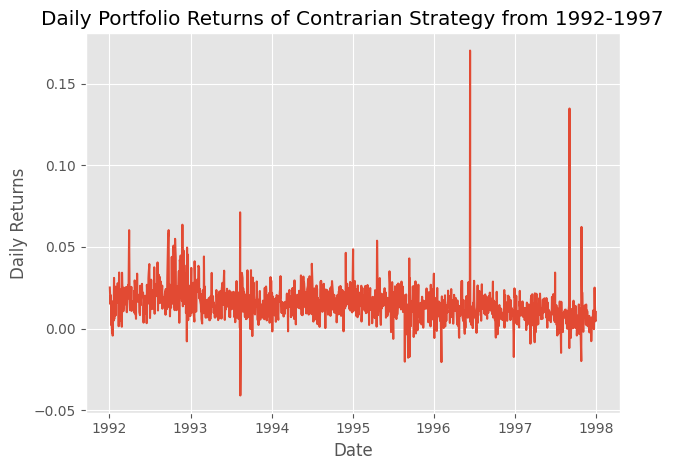

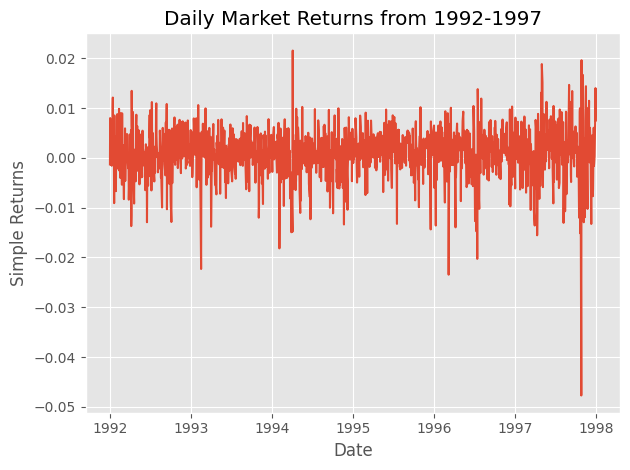

   mean_ann   vol_ann     sharpe
k                               
1  3.724668  0.174427  21.353769
2  0.283507  0.118817   2.386068
3  0.165506  0.123786   1.337033
4  0.120330  0.109460   1.099306
5  0.055100  0.115171   0.478420


In [44]:
#Running Contrarian Strategy from K = 1-5 + Preparing flat file

pid = 901724161
results = []
all_flats = []

#SECTION 1A and 1B: Contrarian Strategy with Stats for K = 1
profit_1, weight_1 = contrarian_strategy(run_return_df, run_excess_df, k = 1)
flat_1 = make_flat_file(weight_1, pid, k = 1, vid = 0)
all_flats.append(flat_1)

#Comparing distributions of strategy and market
strat_mean = profit_1.mean() * 252
strat_vol = profit_1.std() * np.sqrt(252)
strat_sharpe = strat_mean / strat_vol

mkt_mean = run_mean_df.mean() * 252
mkt_vol = run_mean_df.std() * np.sqrt(252)
mkt_sharpe = mkt_mean / mkt_vol

results.append({"k": 1, "mean_ann": strat_mean, "vol_ann": strat_vol, "sharpe": strat_sharpe})

print(f'Strategy Results: Annualized Mean: {strat_mean}, Annualized Vol: {strat_vol}, Sharpe Ratio: {strat_sharpe}')
print(f'Market Results: Annualized Mean: {mkt_mean}, Annualized Vol: {mkt_vol}, Sharpe Ratio: {mkt_sharpe}')

#Daily Portfolio Returns
plt.style.use("ggplot")
plt.figure()
plt.plot(profit_1.index, profit_1.values)
plt.title("Daily Portfolio Returns of Contrarian Strategy from 1992-1997")
plt.xlabel("Date")
plt.ylabel("Daily Returns")
plt.tight_layout()
plt.show()

#Daily Market Returns
plt.figure()
plt.plot(run_mean_df.index, run_mean_df.values)
plt.title("Daily Market Returns from 1992-1997")
plt.xlabel("Date")
plt.ylabel("Simple Returns")
plt.tight_layout()
plt.show()

#SECTION 2A: Contrarian Strategy with Stats for K = 1-5
for k in range(2, 6):
    profit_k, weight_k = contrarian_strategy(run_return_df, run_excess_df, k)
    flat_k = make_flat_file(weight_k, pid, k = k, vid = 0)

    strat_mean = profit_k.mean() * 252
    strat_vol = profit_k.std() * np.sqrt(252)
    strat_sharpe = strat_mean / strat_vol

    mkt_mean = run_mean_df.mean() * 252
    mkt_vol = run_mean_df.std() * np.sqrt(252)
    mkt_sharpe = mkt_mean / mkt_vol

    results.append({"k": k, "mean_ann": strat_mean, "vol_ann": strat_vol, "sharpe": strat_sharpe})
    all_flats.append(flat_k)

strategy_df = pd.DataFrame(results).set_index("k")
print(strategy_df)

flat_all = pd.concat(all_flats, ignore_index = True)
assert flat_all["w"].isna().sum() == 0
assert (flat_all["w"] == 0).sum() == 0
assert flat_all.duplicated(subset = ["pid", "d", "id", "k", "vid"]).sum() == 0

flat_all.to_csv("port_weights.csv", index = False)

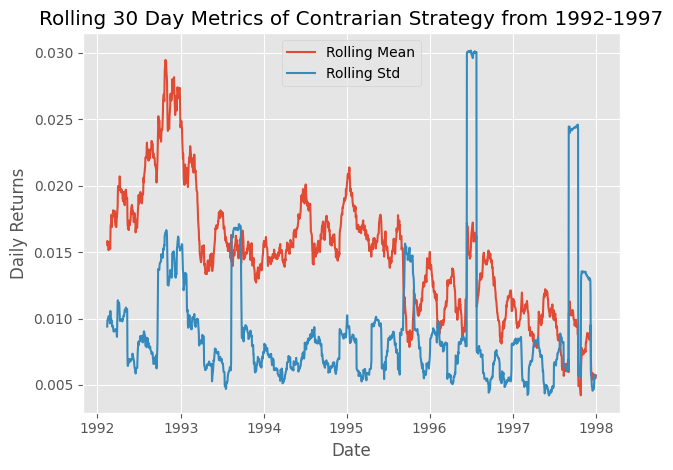

In [20]:
#SECTION ONE PARTS C-I: Further Analysis

#Part C
rolling_prof = profit_1.rolling(30).mean().dropna()
rolling_std = profit_1.rolling(30).std().dropna()

plt.figure()
plt.plot(rolling_prof.index, rolling_prof.values, label='Rolling Mean')
plt.plot(rolling_std.index, rolling_std.values, label='Rolling Std')
plt.title("Rolling 30 Day Metrics of Contrarian Strategy from 1992-1997")
plt.xlabel("Date")
plt.ylabel("Daily Returns")
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
#Part D - looking an unusual events to try to explain outliers
best_days = profit_1.nlargest(10)
# print(best_days)
worst_days = profit_1.nsmallest(10)
# print(worst_days)

#Assuming normal IID, find all 3-sigma days
z = (profit_1 - profit_1.mean()) / profit_1.std()
unusual_days = profit_1[abs(z) > 3]
print(unusual_days.sort_values())

# Create a new DF without the unusual days
clean_profit = profit_1.drop(unusual_days.index)

strat_mean = profit_1.mean() * 252
strat_vol = profit_1.std() * np.sqrt(252)
strat_sharpe = strat_mean / strat_vol

clean_mean = clean_profit.mean() * 252
clean_vol = clean_profit.std() * np.sqrt(252)
clean_sharpe = clean_mean / clean_vol

print(f"Original: Mean: {strat_mean}, Vol: {strat_vol}, Sharpe: {strat_sharpe}")
print(f"Cleaned: Mean: {clean_mean}, Vol: {clean_vol}, Sharpe: {clean_sharpe}")

#TODO: Find what stocks are driving the top 2 best days in particular (6/13/1996, 9/4/1997)


d
1993-08-13   -0.041034
1996-02-05   -0.020569
1995-08-24   -0.020308
1997-10-27   -0.019949
1995-01-03    0.048540
1992-09-21    0.049323
1992-12-16    0.049608
1992-10-16    0.050778
1995-04-21    0.053799
1992-10-23    0.054943
1992-09-23    0.056998
1992-09-22    0.057941
1992-03-30    0.060250
1992-09-24    0.060276
1997-10-28    0.062230
1992-11-25    0.063606
1993-08-12    0.071174
1997-09-04    0.134792
1996-06-13    0.170289
dtype: float64
Original: Mean: 3.7246682385335554, Vol: 0.17442673439050632, Sharpe: 21.35376925761147
Cleaned: Mean: 3.613327785977038, Vol: 0.1383929090533658, Sharpe: 26.10919743426811


In [22]:
#Part E
correlation = profit_1.corr(run_mean_df.loc[profit_1.index])
print(correlation) #Correlation small, seems market-neutral as well as dollar-neutral (by construction)

0.03921792084695991


In [23]:
#Part F
auto_correlation = profit_1.corr(profit_1.shift(1).loc[profit_1.index])
print(auto_correlation)

0.19823650863878628


In [24]:
#Part G
cumulative = (1 + profit_1).cumprod()
rolling_max = cumulative.cummax()
drawdown = (cumulative - rolling_max) / rolling_max
max_drawdown = drawdown.min()
print(max_drawdown)

-0.04997638352777312


In [25]:
#Part H
long_profit_1, short_profit_1 = contrarian_strategy(run_return_df, run_excess_df, k = 1, separate_ls=True)
ls_corr = long_profit_1.corr(short_profit_1)
print(ls_corr)

-0.27353108642366164


In [26]:
#SECTION THREE: Creating new strategies: anti-revert, trend-following, dispersion-boosted

def anti_revert_strategy(return_df, excess_df, k, separate_ls = False):
    '''
        Takes dataframes of simple and excess returns and a lag variable k and constructs a trend strategy with weights
            based on the positive excess return exactly k days ago.
        Returns a dataframe of strategy profits per day
    '''
    weight_df = (excess_df.shift(k - 1)).fillna(0)
    if separate_ls:
        long_weights, short_weights = normalize_weights(weight_df, separate_ls=separate_ls)

        #Find daily portfolio returns
        weight_1_lag = (long_weights.shift(1)).fillna(0)
        profit = (weight_1_lag * return_df).sum(axis = 1)
        long_profit = profit.iloc[k:]

        #Find daily portfolio returns
        weight_1_lag = (short_weights.shift(1)).fillna(0)
        profit = (weight_1_lag * return_df).sum(axis = 1)
        short_profit = profit.iloc[k:]
        return long_profit, short_profit
    else:
        norm_weight_df = normalize_weights(weight_df, separate_ls=separate_ls)

        #Data checks - ensure dates and columns are the same
        assert norm_weight_df.index.equals(return_df.index)
        assert norm_weight_df.columns.equals(return_df.columns)

        #Find daily portfolio returns
        weight_1_lag = (norm_weight_df.shift(1)).fillna(0)
        profit = (weight_1_lag * return_df).sum(axis = 1)
        profit = profit.iloc[k:]
        return profit

def trend_strategy(return_df, excess_df, k, separate_ls = False):
    '''
        Takes dataframes of simple and excess returns and a lag variable k and constructs a trend-following strategy with weights
            based on the rolling excess returns across k days ago.
        Returns a dataframe of strategy profits per day
    '''
    # Form weights based on cumulative excess return over past k days
    cumulative_excess = excess_df.rolling(k).sum()
    weight_df = cumulative_excess.shift(1).fillna(0)  # buy winners, sell losers
    if separate_ls:
        long_weights, short_weights = normalize_weights(weight_df, separate_ls=separate_ls)

        #Find daily portfolio returns
        weight_1_lag = (long_weights.shift(1)).fillna(0)
        profit = (weight_1_lag * return_df).sum(axis = 1)
        long_profit = profit.iloc[k:]

        #Find daily portfolio returns
        weight_1_lag = (short_weights.shift(1)).fillna(0)
        profit = (weight_1_lag * return_df).sum(axis = 1)
        short_profit = profit.iloc[k:]
        return long_profit, short_profit
    else:
        norm_weight_df = normalize_weights(weight_df, separate_ls=separate_ls)

        #Data checks - ensure dates and columns are the same
        assert norm_weight_df.index.equals(return_df.index)
        assert norm_weight_df.columns.equals(return_df.columns)

        #Find daily portfolio returns
        weight_1_lag = (norm_weight_df.shift(1)).fillna(0)
        profit = (weight_1_lag * return_df).sum(axis = 1)
        profit = profit.iloc[k:]
        return profit

#Helper functions for dispersion-boosted trading strategy
def bucket_weights(signal_df, topq, bottomq):
    """
        Takes the signal df (a transformation of excess returns) and returns a combined L/S dollar-neutral weight matrix equal-weighted across the top and bottom quartiles
    """

    def row_bucket(s):
        high = s.quantile(topq)
        low = s.quantile(bottomq)

        long_names = s.index[s > high]
        short_names = s.index[s < low]
        assert len(long_names) > 0 and len(short_names) > 0

        weights = pd.Series(0.0, index = s.index)
        weights.loc[long_names] = -1.0 / len(long_names) #contrarian strategy
        weights.loc[short_names] = 1.0 / len(short_names)

        return weights

    w = signal_df.apply(row_bucket, axis = 1) #Want to apply the buckets cross-sectionally (top/bottom performers each day)
    return w #.reindex(columns = signal_df.columns).fillna(0.0)


def dispersion_indicator(excess_df, dis_roll, dis_threshold):
    #Dispersion regime if cross-sectional standard deviation over dis_roll days is on average greater than dis_threshold
    #Note: dis_threshold in units of decimal volatility (0.01 = 1% volatility)
    return (excess_df.std(axis = 1).rolling(dis_roll).mean() > dis_threshold).astype(float)

#Dispersion-Boosted Trend Trading Strategy
def dispersion_boosted_strategy(return_df, excess_df, mom_roll, dis_roll, dis_threshold):
    #Figure out buckets based on stocks' cumulative excess returns over k days
    # nan_symbols = excess_df.isna().sum()
    # print(nan_symbols[nan_symbols != 0])
    cumulative_excess = excess_df.rolling(mom_roll).sum().dropna(how='all')

    #Identify if dispersion regime or not - binary vector
    regime = dispersion_indicator(excess_df, dis_roll, dis_threshold) #column vector dimensions

    #Create weight buckets for dispersion vs. non-dispersion regime
    #Under dispersion regime, stocks have more idiosyncratic volatility - take advantage of it by concentrating contrarian strategy to the top/bottom performers
    w_dis = bucket_weights(cumulative_excess, topq = 0.9, bottomq = 0.1)
    #When not in dispersion regime, stocks move more together, look more like the market
    w_reg = bucket_weights(cumulative_excess, topq = 0.8, bottomq = 0.2)

    weight = w_reg.mul(1.0 - regime, axis = 0) + w_dis.mul(regime, axis = 0)
    weight_1_lag = (weight.shift(1)).fillna(0)

    profit = (weight_1_lag * return_df).sum(axis = 1)
    first = max(mom_roll, dis_roll) + 1 #momentum strategy with dispersion regime needs this many days to generate a first valid value
    profit = profit.iloc[first:]
    return profit


Strategy Results: Annualized Mean: 0.038616480982084075, Annualized Vol: 0.10833000682112635, Sharpe Ratio: 0.3564707703364895
Market Results: Annualized Mean: 0.22761943965382975, Annualized Vol: 0.07799526840017582, Sharpe Ratio: 2.9183749773892265


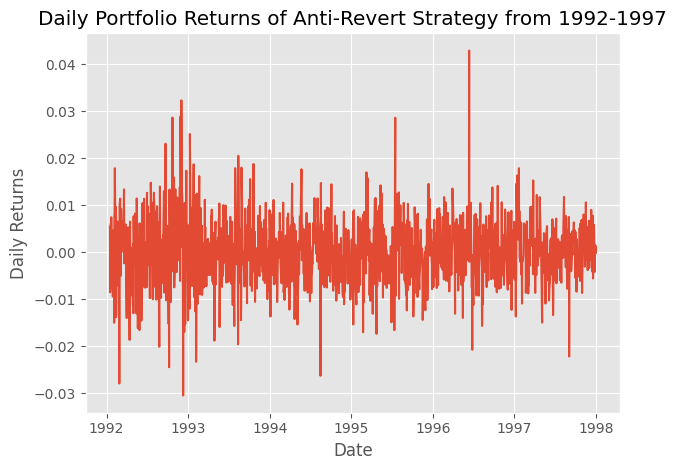

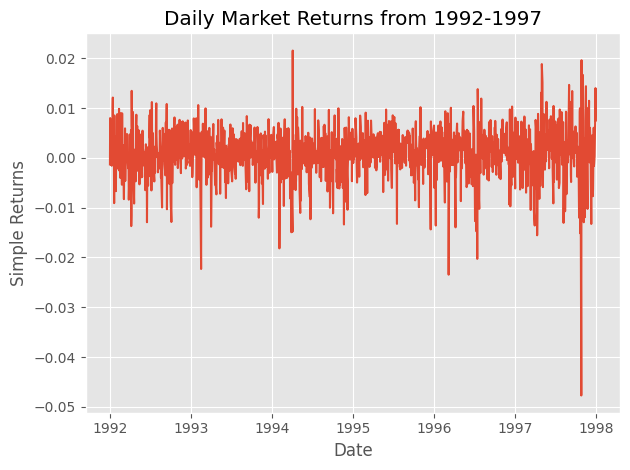

    mean_ann   vol_ann    sharpe
k                               
10  0.038616  0.108330  0.356471
20 -0.002789  0.107555 -0.025927
40 -0.013840  0.097120 -0.142500
60 -0.011634  0.096163 -0.120982
80  0.029158  0.097679  0.298504


In [27]:
#Running Three Alternate Strategies: Anti-Revert

results = []

#Alternate Strategies with Stats for K = 10
profit_antirev = anti_revert_strategy(run_return_df, run_excess_df, k = 10)

#Comparing distributions of strategy and market
strat_mean = profit_antirev.mean() * 252
strat_vol = profit_antirev.std() * np.sqrt(252)
strat_sharpe = strat_mean / strat_vol

mkt_mean = run_mean_df.mean() * 252
mkt_vol = run_mean_df.std() * np.sqrt(252)
mkt_sharpe = mkt_mean / mkt_vol

results.append({"k": 10, "mean_ann": strat_mean, "vol_ann": strat_vol, "sharpe": strat_sharpe})

print(f'Strategy Results: Annualized Mean: {strat_mean}, Annualized Vol: {strat_vol}, Sharpe Ratio: {strat_sharpe}')
print(f'Market Results: Annualized Mean: {mkt_mean}, Annualized Vol: {mkt_vol}, Sharpe Ratio: {mkt_sharpe}')

#Daily Portfolio Returns
plt.style.use("ggplot")
plt.figure()
plt.plot(profit_antirev.index, profit_antirev.values)
plt.title("Daily Portfolio Returns of Anti-Revert Strategy from 1992-1997")
plt.xlabel("Date")
plt.ylabel("Daily Returns")
plt.tight_layout()
plt.show()

#Daily Market Returns
plt.figure()
plt.plot(run_mean_df.index, run_mean_df.values)
plt.title("Daily Market Returns from 1992-1997")
plt.xlabel("Date")
plt.ylabel("Simple Returns")
plt.tight_layout()
plt.show()

#Anti-Revert Strategy with Stats for Various K
for k in range(20, 100, 20):
    profit_k = anti_revert_strategy(run_return_df, run_excess_df, k)

    strat_mean = profit_k.mean() * 252
    strat_vol = profit_k.std() * np.sqrt(252)
    strat_sharpe = strat_mean / strat_vol

    mkt_mean = run_mean_df.mean() * 252
    mkt_vol = run_mean_df.std() * np.sqrt(252)
    mkt_sharpe = mkt_mean / mkt_vol

    results.append({"k": k, "mean_ann": strat_mean, "vol_ann": strat_vol, "sharpe": strat_sharpe})

strategy_df = pd.DataFrame(results).set_index("k")
print(strategy_df)

Strategy Results: Annualized Mean: -0.2906321041911118, Annualized Vol: 0.09991504650634953, Sharpe Ratio: -2.9087921624761726
Market Results: Annualized Mean: 0.22761943965382975, Annualized Vol: 0.07799526840017582, Sharpe Ratio: 2.9183749773892265


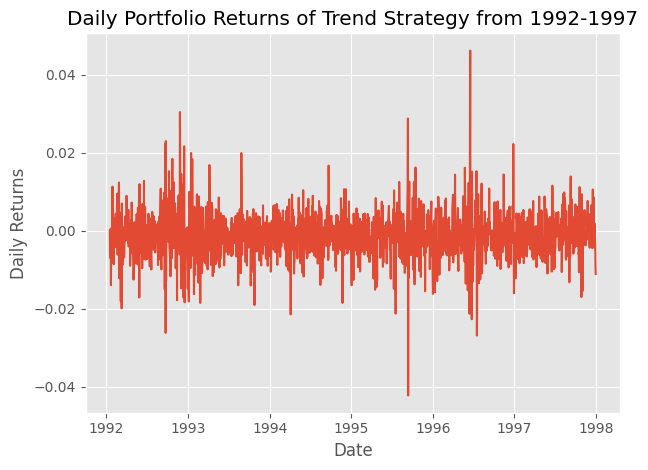

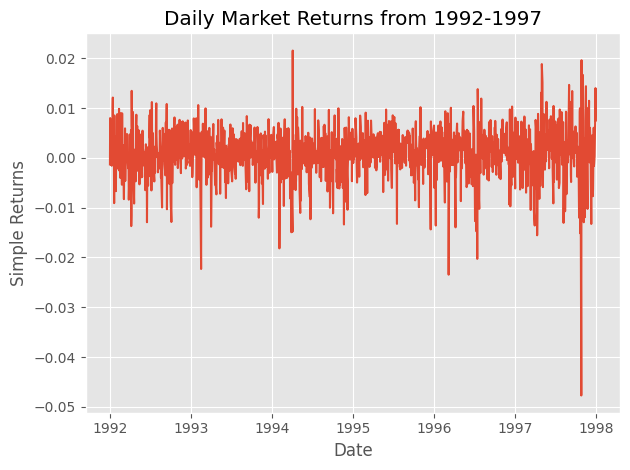

    mean_ann   vol_ann    sharpe
k                               
10 -0.290632  0.099915 -2.908792
20 -0.225009  0.095183 -2.363966
40 -0.168394  0.087813 -1.917655
60 -0.137272  0.087086 -1.576291
80 -0.106585  0.087025 -1.224764


In [28]:
#Running Three Alternate Strategies: Trend

results = []

#Alternate Strategies with Stats for K = 10
profit_trend = trend_strategy(run_return_df, run_excess_df, k = 10)

#Comparing distributions of strategy and market
strat_mean = profit_trend.mean() * 252
strat_vol = profit_trend.std() * np.sqrt(252)
strat_sharpe = strat_mean / strat_vol

mkt_mean = run_mean_df.mean() * 252
mkt_vol = run_mean_df.std() * np.sqrt(252)
mkt_sharpe = mkt_mean / mkt_vol

results.append({"k": 10, "mean_ann": strat_mean, "vol_ann": strat_vol, "sharpe": strat_sharpe})

print(f'Strategy Results: Annualized Mean: {strat_mean}, Annualized Vol: {strat_vol}, Sharpe Ratio: {strat_sharpe}')
print(f'Market Results: Annualized Mean: {mkt_mean}, Annualized Vol: {mkt_vol}, Sharpe Ratio: {mkt_sharpe}')

#Daily Portfolio Returns
plt.style.use("ggplot")
plt.figure()
plt.plot(profit_trend.index, profit_trend.values)
plt.title("Daily Portfolio Returns of Trend Strategy from 1992-1997")
plt.xlabel("Date")
plt.ylabel("Daily Returns")
plt.tight_layout()
plt.show()

#Daily Market Returns
plt.figure()
plt.plot(run_mean_df.index, run_mean_df.values)
plt.title("Daily Market Returns from 1992-1997")
plt.xlabel("Date")
plt.ylabel("Simple Returns")
plt.tight_layout()
plt.show()

#Anti-Revert Strategy with Stats for Various K
for k in range(20, 100, 20):
    profit_k = trend_strategy(run_return_df, run_excess_df, k)

    strat_mean = profit_k.mean() * 252
    strat_vol = profit_k.std() * np.sqrt(252)
    strat_sharpe = strat_mean / strat_vol

    mkt_mean = run_mean_df.mean() * 252
    mkt_vol = run_mean_df.std() * np.sqrt(252)
    mkt_sharpe = mkt_mean / mkt_vol

    results.append({"k": k, "mean_ann": strat_mean, "vol_ann": strat_vol, "sharpe": strat_sharpe})

strategy_df = pd.DataFrame(results).set_index("k")
print(strategy_df)

Strategy Results: Annualized Mean: 2.1557448696747468, Annualized Vol: 0.12432984037275246, Sharpe Ratio: 17.338917698370903
Market Results: Annualized Mean: 0.22761943965382975, Annualized Vol: 0.07799526840017582, Sharpe Ratio: 2.9183749773892265


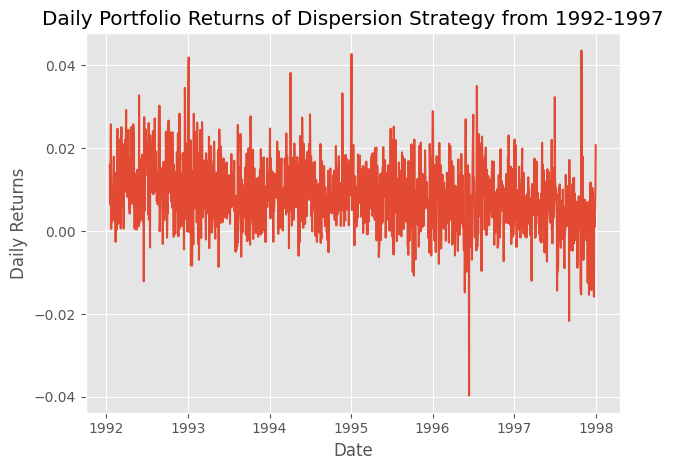

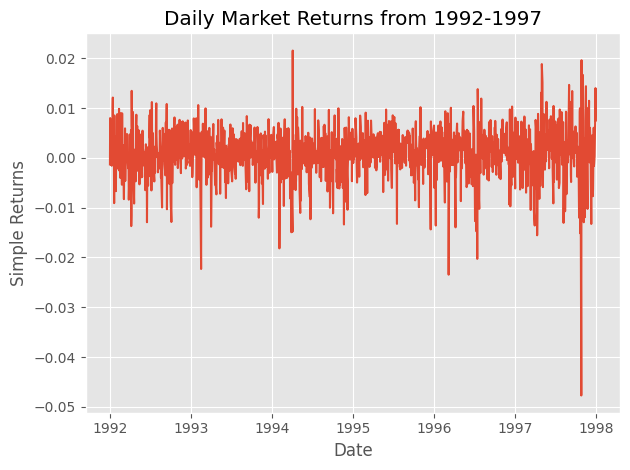

    mean_ann   vol_ann     sharpe
k                                
10  2.155745  0.124330  17.338918
20  1.555110  0.117282  13.259524
40  1.134126  0.113393  10.001718
60  0.973744  0.111069   8.766995
80  0.774398  0.111462   6.947664


In [29]:
#Running Three Alternate Strategies: Dispersion

results = []

#Alternate Strategies with Stats for K = 10
profit_disp = dispersion_boosted_strategy(run_return_df, run_excess_df, mom_roll = 10, dis_roll = 10, dis_threshold = 0.01)

#Comparing distributions of strategy and market
strat_mean = profit_disp.mean() * 252
strat_vol = profit_disp.std() * np.sqrt(252)
strat_sharpe = strat_mean / strat_vol

mkt_mean = run_mean_df.mean() * 252
mkt_vol = run_mean_df.std() * np.sqrt(252)
mkt_sharpe = mkt_mean / mkt_vol

results.append({"k": 10, "mean_ann": strat_mean, "vol_ann": strat_vol, "sharpe": strat_sharpe})

print(f'Strategy Results: Annualized Mean: {strat_mean}, Annualized Vol: {strat_vol}, Sharpe Ratio: {strat_sharpe}')
print(f'Market Results: Annualized Mean: {mkt_mean}, Annualized Vol: {mkt_vol}, Sharpe Ratio: {mkt_sharpe}')

#Daily Portfolio Returns
plt.style.use("ggplot")
plt.figure()
plt.plot(profit_disp.index, profit_disp.values)
plt.title("Daily Portfolio Returns of Dispersion Strategy from 1992-1997")
plt.xlabel("Date")
plt.ylabel("Daily Returns")
plt.tight_layout()
plt.show()

#Daily Market Returns
plt.figure()
plt.plot(run_mean_df.index, run_mean_df.values)
plt.title("Daily Market Returns from 1992-1997")
plt.xlabel("Date")
plt.ylabel("Simple Returns")
plt.tight_layout()
plt.show()

#Anti-Revert Strategy with Stats for Various K
for k in range(20, 100, 20):
    profit_k = dispersion_boosted_strategy(run_return_df, run_excess_df, mom_roll = k, dis_roll = k, dis_threshold = 0.01)

    strat_mean = profit_k.mean() * 252
    strat_vol = profit_k.std() * np.sqrt(252)
    strat_sharpe = strat_mean / strat_vol

    mkt_mean = run_mean_df.mean() * 252
    mkt_vol = run_mean_df.std() * np.sqrt(252)
    mkt_sharpe = mkt_mean / mkt_vol

    results.append({"k": k, "mean_ann": strat_mean, "vol_ann": strat_vol, "sharpe": strat_sharpe})

strategy_df = pd.DataFrame(results).set_index("k")
print(strategy_df)

In [30]:
#SECTION FOUR: Out of Sample Analysis

testingdf = pd.read_excel(
    "testing_data.xlsx",
    header = 0,
    usecols = ["d", "id", "r", "company"],
    parse_dates = ["d"]
)

In [31]:
#Two Three Year Period Dataframes

test1df = testingdf[(testingdf["d"] >= "1998-01-02") & (testingdf["d"] <= "2001-01-01")]
test1df["r_simple"] = np.expm1(test1df["r"])
rtest1df = test1df.pivot(index = "d", columns = "id", values = "r_simple")
rtest1bar = rtest1df.mean(axis = 1)
ntest1bar = rtest1df.count(axis = 1)

r1_excess_df = rtest1df.sub(rtest1bar, axis = 0)
print(r1_excess_df.head(10))

# print(test1df.isna().sum().sum())
# print(test1df.head(10))
# print(test1df.tail(10))

test2df = testingdf[(testingdf["d"] >= "2001-01-01") & (testingdf["d"] <= "2004-01-01")]
test2df["r_simple"] = np.expm1(test2df["r"])
rtest2df = test2df.pivot(index = "d", columns = "id", values = "r_simple")
rtest2bar = rtest2df.mean(axis = 1)
ntest2bar = rtest2df.count(axis = 1)

r2_excess_df = rtest2df.sub(rtest2bar, axis = 0)
print(r2_excess_df.head(10))

# print(test2df.isna().sum().sum())
# print(test2df.head(10))
# print(test2df.tail(10))

id             10137     10225     10401     10488     10516     10656  \
d                                                                        
1998-01-02 -0.004888  0.002566 -0.039862  0.005807  0.000885  0.031339   
1998-01-05 -0.015152 -0.013186  0.009887 -0.019283  0.003206  0.029952   
1998-01-06  0.000136  0.004581  0.018550  0.027995 -0.015036 -0.026496   
1998-01-07 -0.011362  0.014512  0.002540 -0.017065  0.064271  0.002540   
1998-01-08  0.010225 -0.000560  0.049936  0.006207  0.000663 -0.017602   
1998-01-09  0.023406 -0.005217 -0.003568  0.045404  0.000324  0.007074   
1998-01-12  0.000758  0.023354  0.024481 -0.030656  0.015901  0.004965   
1998-01-13 -0.023538  0.002182  0.033576  0.013702 -0.014317  0.000865   
1998-01-14  0.001937  0.020904  0.000557 -0.001234 -0.011790 -0.012257   
1998-01-15 -0.015086  0.001301 -0.009473  0.002950  0.000114 -0.015479   

id             10866     10890     11308     11404  ...     81294     81614  \
d                               

Contrarian Strategy Results: Annualized Mean: 1.994523514584782, Annualized Vol: 0.2169305345724984, Sharpe Ratio: 6.947664167595079
Dispersion Strategy Results: Annualized Mean: 1.337395575571258, Annualized Vol: 0.1930152495690862, Sharpe Ratio: 6.928963273922885
Market Results: Annualized Mean: 0.09733772469056612, Annualized Vol: 0.13144226120723432, Sharpe Ratio: 0.7405359874104848


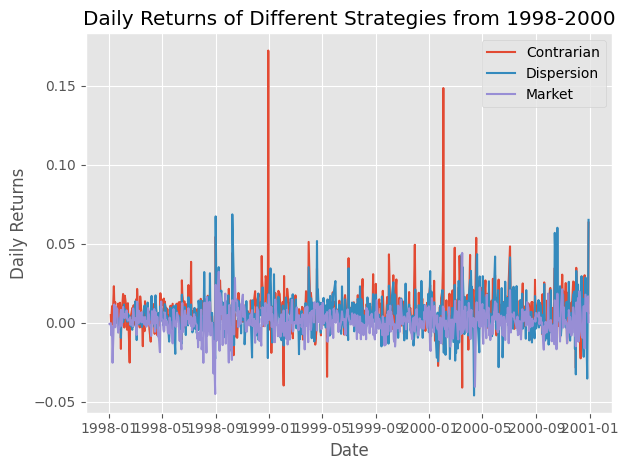

Contrarian Strategy Results: Annualized Mean: 1.7810212692850016, Annualized Vol: 0.2352562078164018, Sharpe Ratio: 6.947664167595079
Dispersion Strategy Results: Annualized Mean: 1.2575444810296355, Annualized Vol: 0.18975471762690055, Sharpe Ratio: 6.627210626205584
Market Results: Annualized Mean: 0.18109293859361397, Annualized Vol: 0.16737306584110853, Sharpe Ratio: 1.0819718076116862


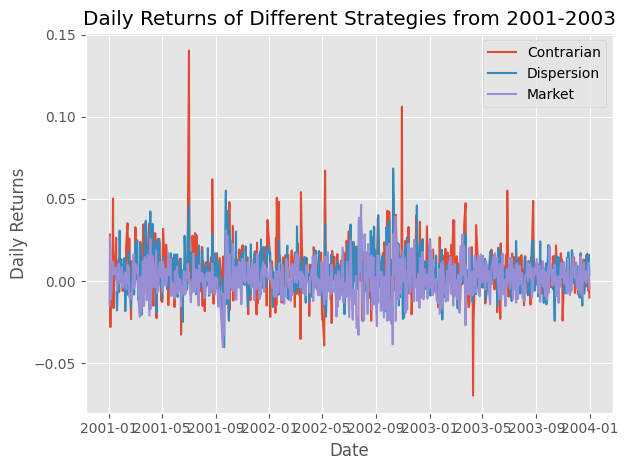

                mean_ann   vol_ann    sharpe
Sample                                      
Cont 1998-2000  1.994524  0.216931  6.947664
Disp 1998-2000  1.337396  0.193015  6.928963
Mkt 1998-2000   0.097338  0.131442  0.740536
Cont 2001-2003  1.781021  0.235256  6.947664
Disp 2001-2003  1.257544  0.189755  6.627211
Mkt 2001-2003   0.181093  0.167373  1.081972


In [34]:
#Run the strategy comparisons

results = []

#1998-2000 Out of Sample
profit_1, weight_1 = contrarian_strategy(rtest1df, r1_excess_df, k = 1)
profit_dis1 = dispersion_boosted_strategy(rtest1df, r1_excess_df, mom_roll = 10, dis_roll = 10, dis_threshold = 0.01)

strat_mean1 = profit_1.mean() * 252
strat_vol1 = profit_1.std() * np.sqrt(252)
strat_sharpe1 = strat_mean / strat_vol

dis_mean1 = profit_dis1.mean() * 252
dis_vol1 = profit_dis1.std() * np.sqrt(252)
dis_sharpe1 = dis_mean1 / dis_vol1

mkt_mean = rtest1bar.mean() * 252
mkt_vol = rtest1bar.std() * np.sqrt(252)
mkt_sharpe = mkt_mean / mkt_vol

results.append({"Sample": "Cont 1998-2000", "mean_ann": strat_mean1, "vol_ann": strat_vol1, "sharpe": strat_sharpe1})
results.append({"Sample": "Disp 1998-2000", "mean_ann": dis_mean1, "vol_ann": dis_vol1, "sharpe": dis_sharpe1})
results.append({"Sample": "Mkt 1998-2000", "mean_ann": mkt_mean, "vol_ann": mkt_vol, "sharpe": mkt_sharpe})

print(f'Contrarian Strategy Results: Annualized Mean: {strat_mean1}, Annualized Vol: {strat_vol1}, Sharpe Ratio: {strat_sharpe1}')
print(f'Dispersion Strategy Results: Annualized Mean: {dis_mean1}, Annualized Vol: {dis_vol1}, Sharpe Ratio: {dis_sharpe1}')
print(f'Market Results: Annualized Mean: {mkt_mean}, Annualized Vol: {mkt_vol}, Sharpe Ratio: {mkt_sharpe}')

#Daily Portfolio Returns
plt.style.use("ggplot")
plt.figure()
plt.plot(profit_1.index, profit_1.values, label = "Contrarian")
plt.plot(profit_dis1.index, profit_dis1.values, label = "Dispersion")
plt.plot(rtest1bar.index, rtest1bar.values, label = "Market")
plt.title("Daily Returns of Different Strategies from 1998-2000")
plt.legend()
plt.xlabel("Date")
plt.ylabel("Daily Returns")
plt.tight_layout()
plt.show()

#2001-2003 Out of Sample
profit_2, weight_2 = contrarian_strategy(rtest2df, r2_excess_df, k = 1)
profit_dis2 = dispersion_boosted_strategy(rtest2df, r2_excess_df, mom_roll = 10, dis_roll = 10, dis_threshold = 0.01)

strat_mean2 = profit_2.mean() * 252
strat_vol2 = profit_2.std() * np.sqrt(252)
strat_sharpe2 = strat_mean / strat_vol

dis_mean2 = profit_dis2.mean() * 252
dis_vol2 = profit_dis2.std() * np.sqrt(252)
dis_sharpe2 = dis_mean2 / dis_vol2

mkt_mean2 = rtest2bar.mean() * 252
mkt_vol2 = rtest2bar.std() * np.sqrt(252)
mkt_sharpe2 = mkt_mean2 / mkt_vol2

results.append({"Sample": "Cont 2001-2003", "mean_ann": strat_mean2, "vol_ann": strat_vol2, "sharpe": strat_sharpe2})
results.append({"Sample": "Disp 2001-2003", "mean_ann": dis_mean2, "vol_ann": dis_vol2, "sharpe": dis_sharpe2})
results.append({"Sample": "Mkt 2001-2003", "mean_ann": mkt_mean2, "vol_ann": mkt_vol2, "sharpe": mkt_sharpe2})

print(f'Contrarian Strategy Results: Annualized Mean: {strat_mean2}, Annualized Vol: {strat_vol2}, Sharpe Ratio: {strat_sharpe2}')
print(f'Dispersion Strategy Results: Annualized Mean: {dis_mean2}, Annualized Vol: {dis_vol2}, Sharpe Ratio: {dis_sharpe2}')
print(f'Market Results: Annualized Mean: {mkt_mean2}, Annualized Vol: {mkt_vol2}, Sharpe Ratio: {mkt_sharpe2}')

#Daily Portfolio Returns
plt.style.use("ggplot")
plt.figure()
plt.plot(profit_2.index, profit_2.values, label = "Contrarian")
plt.plot(profit_dis2.index, profit_dis2.values, label = "Dispersion")
plt.plot(rtest2bar.index, rtest2bar.values, label = "Market")
plt.title("Daily Returns of Different Strategies from 2001-2003")
plt.legend()
plt.xlabel("Date")
plt.ylabel("Daily Returns")
plt.tight_layout()
plt.show()

strategy_df = pd.DataFrame(results).set_index("Sample")
print(strategy_df)